In [1]:
import os
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


import cv2
from PIL import Image, UnidentifiedImageError
from skimage.morphology import dilation, erosion, square
from skimage.exposure import equalize_hist

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [5]:
# Load data
def nested_defaultdict():
    return defaultdict(list)

class CTScanLoader:
    """Loader for CT scan dataset with error handling and visualization."""
    
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.dataset = defaultdict(nested_defaultdict)
        self.classes = {
            'adenocarcinoma': 0,
            'large.cell.carcinoma': 1,
            'squamous.cell.carcinoma': 2,
            'normal': 3
        }
        self._load_data()
    
    def _load_data(self):
        """Load and organize data by split and class."""
        for split in ['train', 'valid', 'test']:
            split_path = os.path.join(self.root_dir, split)
            if not os.path.exists(split_path):
                print(f"{split} directory not found")
                continue
            
            for class_name in self.classes:
                class_path = os.path.join(split_path, class_name)
                if not os.path.exists(class_path):
                    print(f"{class_name} directory missing in {split}")
                    continue
                
                self._process_images(split, class_name, class_path)
    
    def _process_images(self, split, class_name, class_path):
        """Validate and store images from directory."""
        try:
            for filename in os.listdir(class_path):
                if not filename.lower().endswith(('.png', '.jpg')):
                    continue
                
                full_path = os.path.join(class_path, filename)
                try:
                    with Image.open(full_path) as img:
                        img.verify()
                    
                    patient_id = self._get_patient_id(filename)
                    self.dataset[split][(class_name, patient_id)].append({
                        'path': full_path,
                        'filename': filename,
                        'class': class_name,
                        'patient_id': patient_id
                    })
                except (IOError, UnidentifiedImageError) as e:
                    print(f"Corrupted image skipped: {filename} - {str(e)}")
        except Exception as e:
            print(f"Error accessing {class_path}: {str(e)}")

    def _get_patient_id(self, filename):
        """Extract patient ID from filename using regex patterns."""
        base_name = os.path.splitext(filename)[0]
        patterns = [
            r'^(\d+)\s*(-\s*Copy\s*)*',
            r'^(\d+)\s*(-\s*Copy\s*)*',
            r'^(\d+)_\d+_\d+_\d+$',   
            r'^(\d+)\s*\(\d+\)',      
            r'^n(\d+)\s*\(\d+\)',     
            r'^(\d+)$',               
            r'^[a-z]*(\d+)',          
            r'^(normal)'               
        ]
        
        for pattern in patterns:
            if match := re.match(pattern, base_name):
                return match.group(1)
        return base_name

    def show_summary(self):
        """Display dataset statistics."""
        for split in ['train', 'valid', 'test']:
            print(f"\n{split.upper()}:")
            if not self.dataset[split]:
                print("No data available")
                continue
            
            total_images = sum(len(imgs) for imgs in self.dataset[split].values())
            print(f"Total Images: {total_images}")
            print(f"Unique Patients: {len(self.dataset[split])}")
            
            print("\nClasses:")
            class_counts = defaultdict(int)
            for (class_name, _), imgs in self.dataset[split].items():
                class_counts[class_name] += len(imgs)
            
            for class_name in sorted(self.classes):
                print(f"{class_name}: {class_counts.get(class_name, 0)}")

    def visualize_samples(self, n=3):
        """Display sample images from each class."""
        for split in self.dataset:
            print(f"\n{split.upper()} samples:")
            
            for class_name in self.classes:
                # Collect all images for this class
                images = []
                for (cls, _), imgs in self.dataset[split].items():
                    if cls == class_name:
                        images.extend(imgs)
                
                if not images:
                    print(f"No images for {class_name}")
                    continue
                
                # Display samples
                plt.figure(figsize=(15, 5))
                plt.suptitle(f"{split}/{class_name}")
                
                for i in range(min(n, len(images))):
                    try:
                        img = Image.open(images[i]['path'])
                        plt.subplot(1, n, i+1)
                        plt.imshow(img, cmap='gray')
                        plt.title(images[i]['filename'], fontsize=8)
                        plt.axis('off')
                    except Exception as e:
                        print(f"Error displaying {images[i]['path']}: {str(e)}")
                
                plt.show()


In [8]:
DATA_PATH = "/Users/julaswiatkowska/Desktop/project/Data"
loader = CTScanLoader(DATA_PATH)
loader.show_summary()
# loader.visualize_samples(n=2)


TRAIN:
Total Images: 613
Unique Patients: 284

Classes:
adenocarcinoma: 195
large.cell.carcinoma: 115
normal: 148
squamous.cell.carcinoma: 155

VALID:
Total Images: 72
Unique Patients: 44

Classes:
adenocarcinoma: 23
large.cell.carcinoma: 21
normal: 13
squamous.cell.carcinoma: 15

TEST:
Total Images: 315
Unique Patients: 167

Classes:
adenocarcinoma: 120
large.cell.carcinoma: 51
normal: 54
squamous.cell.carcinoma: 90


In [9]:
# Check the image paths and image mode
sample_class = next(iter(loader.dataset['train'].keys()))  # Get first class
sample_image_info = loader.dataset['train'][sample_class][0]  # Get first image
sample_path = sample_image_info['path']  # Extract path

#print(f"Sample image path: {sample_path}")
sample_img = Image.open(sample_path)
#print(f"Image mode: {sample_img.mode}")  
sample_img.close() 

In [5]:
# Images Enhancement

class CTScanEnhancer:
    """Applying the images enhancement techniques to CT scans"""

    def __init__(self):
        self.clahe_params = {
            'clip_limit': 2.0,
            'tile_grid_size': (8,8) # 64 blocks
        }
        self.morph_kernel = square(3)

    def _to_array(self, image):
        """Convert PIL Image to RGB numpy array"""
        if isinstance(image, Image.Image):
            return np.array(image.convert('RGB'))  # Force RGB conversion
        return image.copy()

    def median_filter(self, image, kernel_size=3):
        """Median filter for RGB images"""
        img_array = self._to_array(image)
        filtered = np.stack([
            cv2.medianBlur(img_array[:, :, i], kernel_size)
            for i in range(3)
        ], axis=-1)
        return Image.fromarray(filtered)

    def hist_equalization(self, image):
        """Histogram equalization in HSV space (preserves color)"""
        img_array = self._to_array(image)
        
        # Convert to HSV, equalize V channel, convert back to RGB
        hsv = cv2.cvtColor(img_array, cv2.COLOR_RGB2HSV)
        hsv[:, :, 2] = (equalize_hist(hsv[:, :, 2]) * 255).astype(np.uint8)
        equalized = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        
        return Image.fromarray(equalized)

    def clahe(self, image):
        """CLAHE for RGB images (applied to each channel)"""
        img_array = self._to_array(image)
        clahe = cv2.createCLAHE(
            clipLimit=self.clahe_params['clip_limit'],
            tileGridSize=self.clahe_params['tile_grid_size']
        )
        clahe_img = np.stack([
            clahe.apply(img_array[:, :, i])
            for i in range(3)
        ], axis=-1)
        return Image.fromarray(clahe_img)

    def morphological_ops(self, image, operations=['open', 'close']):
        """Morphological operations for RGB (per-channel)"""
        img_array = self._to_array(image)
        
        result = np.zeros_like(img_array)
        for i in range(3):  # Process each channel
            channel = img_array[:, :, i]
            for op in operations:
                if op == 'open':
                    channel = erosion(channel, self.morph_kernel)
                    channel = dilation(channel, self.morph_kernel)
                elif op == 'close':
                    channel = dilation(channel, self.morph_kernel)
                    channel = erosion(channel, self.morph_kernel)
            result[:, :, i] = channel
            
        return Image.fromarray(result)

    def full_pipeline(self, image):
        """Complete RGB enhancement pipeline"""
        # Step 1: Median Filter
        enhanced = self.median_filter(image)
        
        # Step 2: Histogram Equalization 
        enhanced = self.hist_equalization(enhanced)
        
        # Step 3: CLAHE
        enhanced = self.clahe(enhanced)
        
        # Step 4: Morphological Operations
        enhanced = self.morphological_ops(enhanced)
        
        return enhanced

    def visualize_enhancement(self, original_path, save_path=None):
        """RGB visualization of all enhancement steps"""
        original = Image.open(original_path).convert('RGB')
        steps = [
            ("1. Original", original),
            ("2. Median Filter", self.median_filter(original)),
            ("3. Histogram Equalization", self.hist_equalization(original)),
            ("4. CLAHE", self.clahe(original)),
            ("5. Morphological Ops", self.morphological_ops(original)),
            ("6. Full Pipeline", self.full_pipeline(original))
        ]
        
        plt.figure(figsize=(18, 12))
        for i, (title, img) in enumerate(steps, 1):
            plt.subplot(2, 3, i)
            plt.imshow(img)
            plt.title(title)
            plt.axis('off')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path)
        plt.show()


In [6]:
enhancer = CTScanEnhancer()

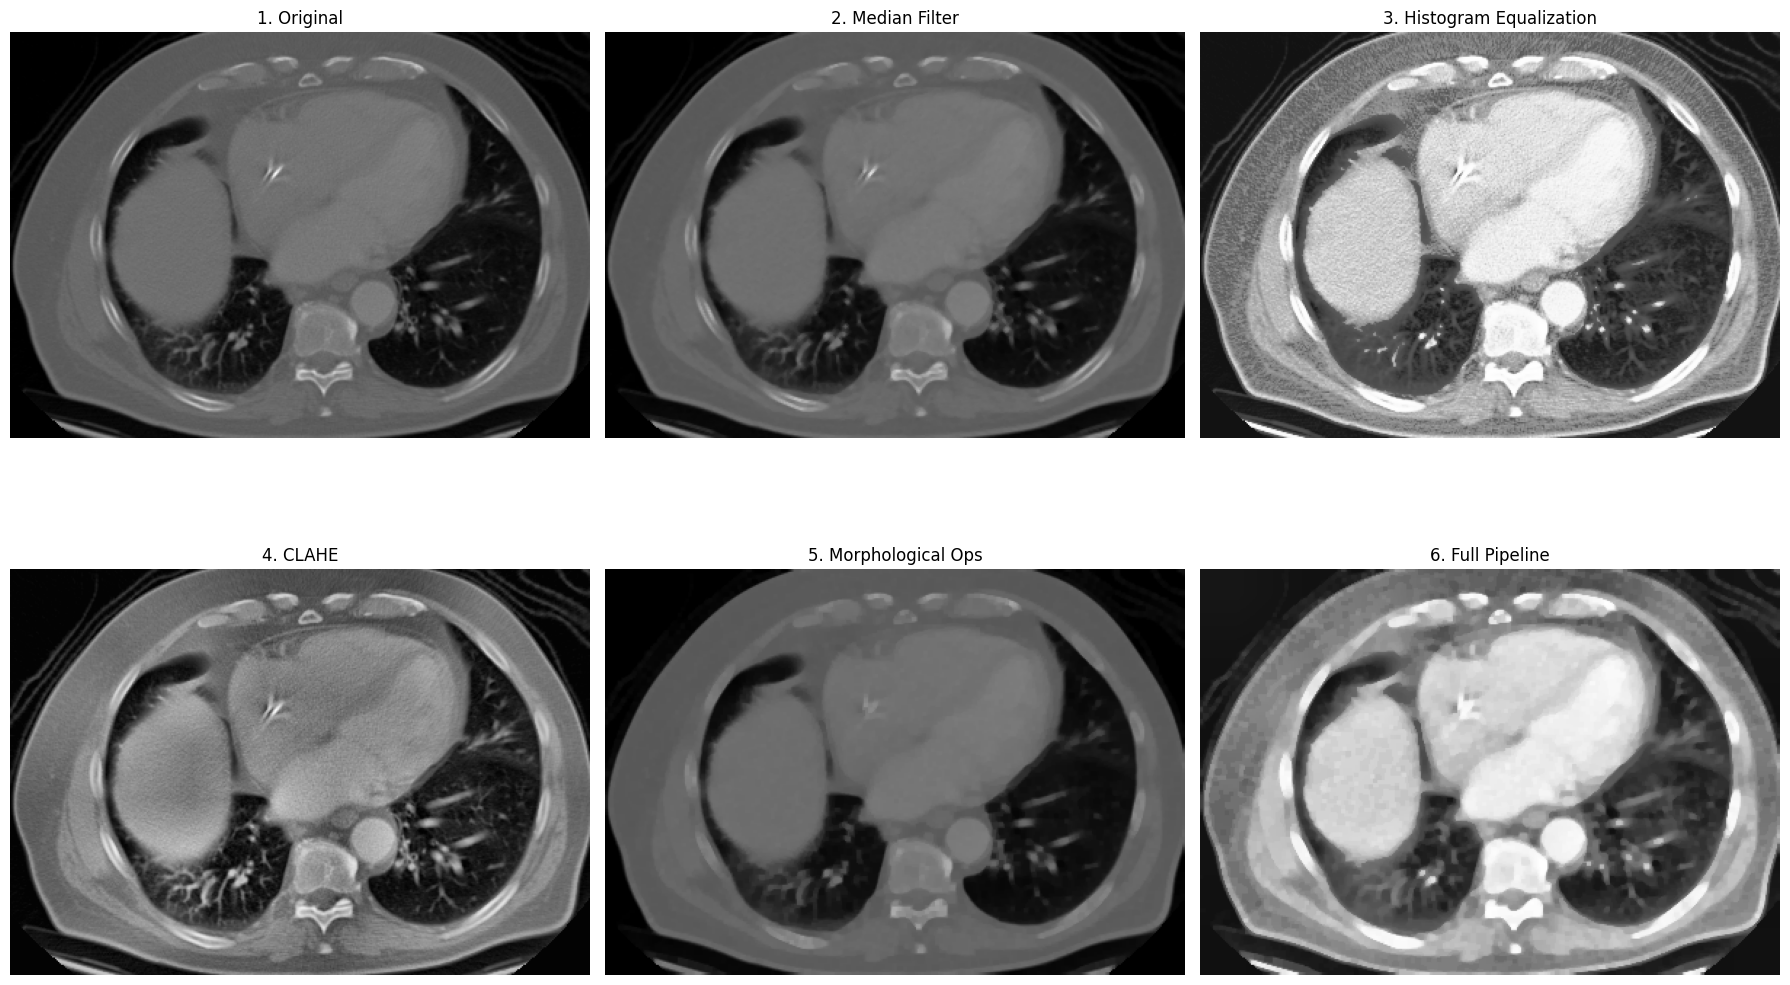

In [7]:
def show_enhancement_on_sample(loader, enhancer, split='train', class_name='adenocarcinoma', n=2):
    images = []
    
    for (cls, _), imgs in loader.dataset[split].items():
        if cls == class_name:
            images.extend(imgs)
        if len(images) >= n:
            break
    
    if not images:
        print(f"No images for class '{class_name}' in split '{split}'")
        return
    
    for i, img_info in enumerate(images[:n]):
        try:
            img = Image.open(img_info['path']).convert('L')
            enhancer.visualize_enhancement(img_info['path'])
        except Exception as e:
            print(f"Error processing {img_info['filename']}: {str(e)}")

show_enhancement_on_sample(loader, enhancer, split='valid', class_name='large.cell.carcinoma', n=1)

In [42]:
# Data pre-processing

# Apply data augmentation

class CTScanDataset(Dataset):
    """PyTorch Dataset for CT scans with full preprocessing pipeline"""
    
    def __init__(self, loader, split='train', target_size=(224, 224), augment=False):
    
        self.loader = loader
        self.split = split
        self.target_size = target_size
        self.augment = augment
        self.enhancer = CTScanEnhancer()

        # Collect all image paths and labels
        self.samples = []
        for (class_name, _), images in self.loader.dataset[split].items():
            class_idx = self.loader.classes[class_name]
            for img_info in images:
                self.samples.append((img_info['path'], class_idx))
    
    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.samples)
    
    def __getitem__(self, idx):
        """Return a single sample from the dataset."""
        img_path, label = self.samples[idx]
        
        try:
            # Load the image
            img = Image.open(img_path).convert('RGB')  # Convert to 3-channels input

            # Apply ehnancement
            img = self.enhancer.full_pipeline(img)

            # Convert back to tensor (here we also normalize the image to [0, 1])
            img = F.to_tensor(img)

            # Resize
            img = F.resize(img, self.target_size)

            # Apply augmentation if it is training
            if self.augment:
                # Random horizontal flip (50% chance)
                if random.random() > 0.5:
                    img = F.hflip(img)
                
                # Random vertical flip (50% chance)
                if random.random() > 0.5:
                    img = F.vflip(img)
                
                # Random affine transformation (shear)
                angle = 0
                translate = (0, 0)
                scale = 1.0
                shear = random.uniform(-0.2, 0.2)  
                
                img = F.affine(img, angle=angle, translate=translate, 
                              scale=scale, shear=shear)
                
            return img, label
            
        except Exception as e:
            print(f"Error loading {img_path}: {str(e)}")
            # Return a zero tensor if image fails to load
            return torch.zeros(3, *self.target_size), -1
        
class CTScanPreprocessor:
    """Preprocessor for CT scans dataset with data augmentation and normalization."""
    
    def __init__(self, loader, batch_size=32, target_size=(224, 224)):
        self.loader = loader
        self.batch_size = batch_size
        self.target_size = target_size
        
        self.dataset = CTScanDataset(loader, split='train', target_size=target_size)
        
        self.dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    
    def get_datasets(self):
        """Create train, validation, and test datasets"""
        train_dataset = CTScanDataset(
            self.loader, split='train', 
            target_size=self.target_size, 
            augment=True
        )
        
        val_dataset = CTScanDataset(
            self.loader, split='valid',
            target_size=self.target_size,
            augment=False
        )
        
        test_dataset = CTScanDataset(
            self.loader, split='test',
            target_size=self.target_size,
            augment=False
        )
        
        return train_dataset, val_dataset, test_dataset
    
    def get_dataloaders(self, num_workers=0):
        """Create DataLoaders for train, validation, and test datasets"""
        train_dataset, val_dataset, test_dataset = self.get_datasets()
        
        train_loader = DataLoader(
            train_dataset, batch_size=self.batch_size, 
            shuffle=True, num_workers=num_workers, pin_memory=True
        )
        
        val_loader = DataLoader(
            val_dataset, batch_size=self.batch_size, 
            shuffle=False, num_workers=num_workers, pin_memory=True
        )
        
        test_loader = DataLoader(
            test_dataset, batch_size=self.batch_size, 
            shuffle=False, num_workers=num_workers, pin_memory=True
        )
        
        return train_loader, val_loader, test_loader
        
    def visualize_samples(self, dataloader, n=2):
        """Visualize a few samples from the DataLoader"""
        images, labels = next(iter(dataloader))
        
        # Reverse class mapping
        class_names = {v: k for k, v in self.loader.classes.items()}
        
        plt.figure(figsize=(15, 10))
        for i in range(min(n, len(images))):
            img = images[i].permute(1, 2, 0)  # CHW to HWC
            if img.shape[2] == 1:  # Grayscale
                img = img.squeeze()
            
            plt.subplot(1, n, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(class_names[labels[i].item()])
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    

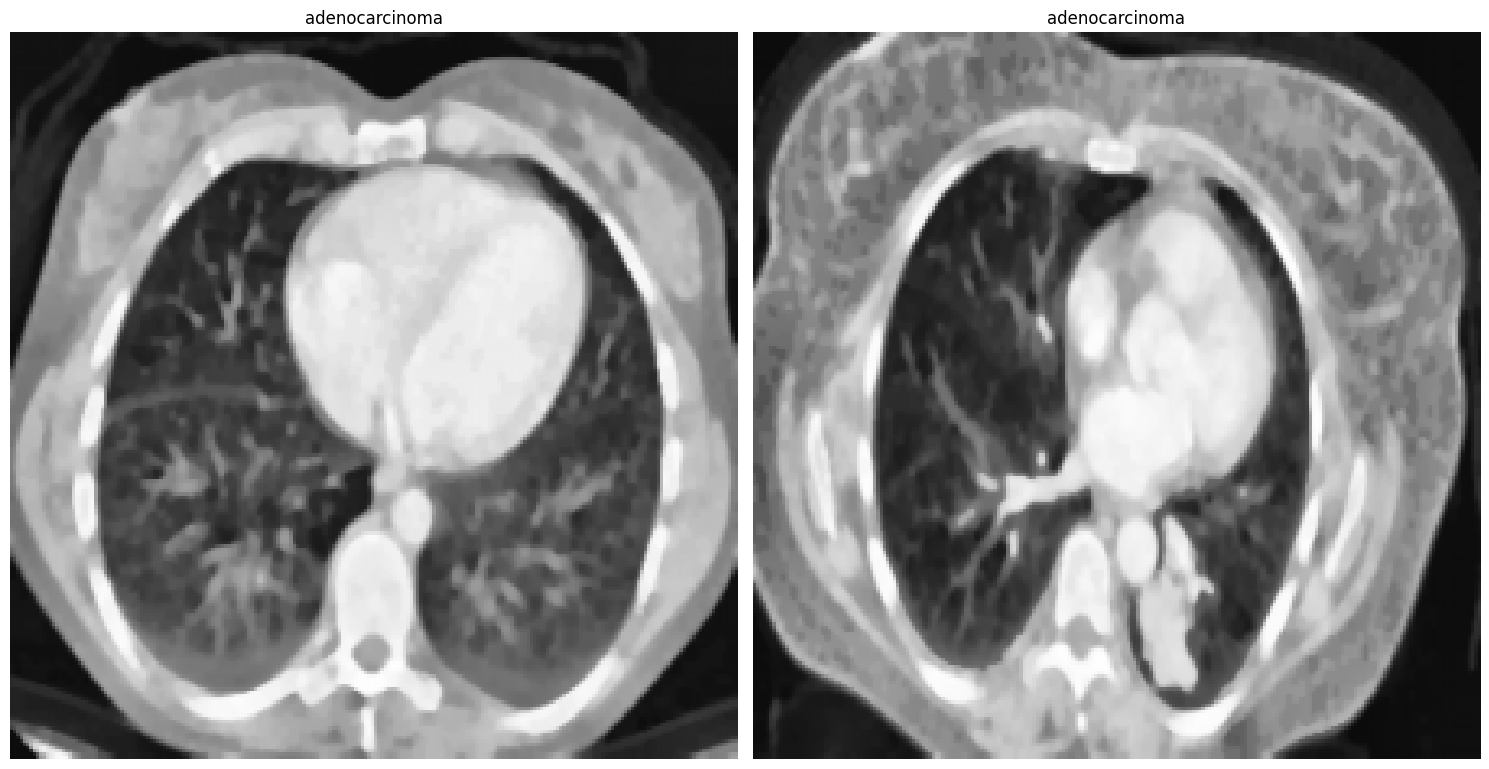

In [43]:
preprocessor = CTScanPreprocessor(loader, target_size=(224, 224), batch_size=32)

# Get dataloaders
train_loader, val_loader, test_loader = preprocessor.get_dataloaders()

# Visualize a validation batch
preprocessor.visualize_samples(val_loader)

In [ ]:
# ResNet50 model

def resnet50(num_classes=4):
    resnet = models.resnet50(weights='IMAGENET1K_V2')

    # To apply Grad CAM layers have to be unfreezed
    for param in resnet.parameters():
        param.requires_grad = True
    
    # 2 FC layers (512 units + output)
    resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
    
    return resnet

In [11]:
def train_resnet(train_loader, val_loader,num_classes=4 , num_epochs=150):
    resnet = resnet50(num_classes).to(device)
    
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(resnet.parameters(), lr = 0.001)
    
    # Early stopping 
    patience = 20
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []
    
    
    for epoch in range(num_epochs):
        resnet.train()
        train_loss = 0.0
        train_correct = 0  
        train_total = 0
        
        # Training phase
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = resnet(images)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)  # Get predictions
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Calculate metrics
        train_accuracy = 100 * train_correct / train_total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        # Validation phase
        resnet.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = resnet(images)
                val_loss += loss_func(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        # Calculate metrics
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)
        
        # Print metrics 
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, "
              f"Train Acc: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, "
              f"Val Acc: {val_accuracy:.2f}%")
        
        # Early stopping
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            epochs_without_improvement = 0
            torch.save(resnet.state_dict(), 'best_model_resnet.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
    # Plotting
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Training Accuracy', color='blue', marker='.')
    plt.plot(val_accuracies, label='Validation Accuracy', color='red', marker='*')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
   
    plt.legend()
    plt.plot(train_losses, label='Training Loss', color='blue', marker='.')
    plt.plot(val_losses, label='Validation Loss', color='red', marker='*')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    resnet.load_state_dict(torch.load('best_model_resnet.pth'))
    
    return resnet

Epoch 1/150: Train Loss: 17.2890, Train Acc: 60.85%, Val Loss: 3.2823, Val Acc: 47.22%
Epoch 2/150: Train Loss: 11.3605, Train Acc: 77.49%, Val Loss: 4.3695, Val Acc: 61.11%
Epoch 3/150: Train Loss: 9.2804, Train Acc: 82.38%, Val Loss: 3.8996, Val Acc: 55.56%
Epoch 4/150: Train Loss: 8.0504, Train Acc: 87.11%, Val Loss: 1.5906, Val Acc: 70.83%
Epoch 5/150: Train Loss: 7.0404, Train Acc: 87.77%, Val Loss: 3.3578, Val Acc: 65.28%
Epoch 6/150: Train Loss: 6.1360, Train Acc: 89.07%, Val Loss: 5.8834, Val Acc: 55.56%
Epoch 7/150: Train Loss: 6.1350, Train Acc: 90.05%, Val Loss: 4.9092, Val Acc: 40.28%
Epoch 8/150: Train Loss: 5.0153, Train Acc: 92.01%, Val Loss: 1.6770, Val Acc: 76.39%
Epoch 9/150: Train Loss: 4.7905, Train Acc: 92.01%, Val Loss: 2.3459, Val Acc: 73.61%
Epoch 10/150: Train Loss: 1.8790, Train Acc: 96.57%, Val Loss: 1.4854, Val Acc: 84.72%
Epoch 11/150: Train Loss: 2.8710, Train Acc: 96.90%, Val Loss: 3.6893, Val Acc: 69.44%
Epoch 12/150: Train Loss: 6.1721, Train Acc: 89.56

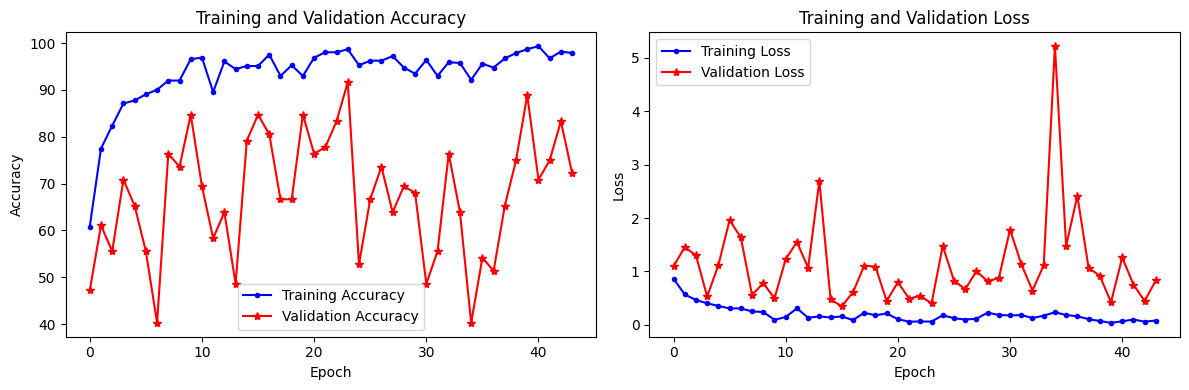

In [12]:
resnet = train_resnet(train_loader=train_loader, val_loader=val_loader, num_classes=4, num_epochs=150)

In [39]:
resnet = resnet50(num_classes=4).to(device)
resnet.load_state_dict(torch.load('best_model_resnet.pth'))
resnet.eval()
print("Pretrained model loaded successfully")

Pretrained model loaded successfully


In [ ]:
# Calculate metrics for ResNet50 model
resnet.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.3619
Precision: 0.6302
Recall: 0.5160
F1-score: 0.3717


In [ ]:
# Custom CNN model

class CustomCNN(nn.Module):
    "Custom, enhanced CNN model"
    
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        # Layer 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        # Layer 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        
        #Layer 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.4))

        # Layer 4: Additional dropout layer
        self.dropout2 = nn.Dropout(0.4)

        # Layer 5 Flattening is handled in forward pass
        # Input size is (224, 224), after 2 max pools it's (224/4, 224/4) = (56, 56)
        self.flattened_size = 32 * 56 * 56

        # Layer 6 dense layer with 256 neurons 
        self.fc1 = nn.Sequential(
            nn.Linear(self.flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4))
        
        # LAyer 7 dense layer with 128 neurons 
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU())
        
        # Layer 8 final dense layer with softmax activation
        self.output = nn.Sequential(
            nn.Linear(128, num_classes),
            nn.Softmax(dim=1)
        )

        # Grad-CAM attributes
        self.gradients = None
        self.activations = None

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        
        # Layer 2
        x = self.conv2(x)
        
        # Layer 3
        x = self.conv3(x)

        # Only register hook during training/evaluation when gradients are needed
        if x.requires_grad: 
            h = x.register_hook(self.activations_hook)
            self.activations = x

        # Layer 4
        x = self.dropout2(x)
        
        # Layer 5: Flatten
        x = x.view(-1, self.flattened_size)
        
        # Layer 6
        x = self.fc1(x)
        
        # Layer 7
        x = self.fc2(x)
        
        # Layer 8
        x = self.output(x)
        
        return x
    
    def get_activations_gradient(self):
        return self.gradients
    
    def get_activations(self):
        return self.activations
    
cnn = CustomCNN()
print(cnn)

CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
  )
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc1): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
  )
  (fc2): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
  )
  (output): Sequential(
    (0): Linear(in_features=128, out_features=4, bias=True)
    (1): Softmax(dim=1)
  )
)


In [16]:
cnn = CustomCNN().to(device)

In [17]:
loss_func = nn.CrossEntropyLoss()

optimizer = optim.Adam(cnn.parameters(), lr = 0.001)

In [31]:
def train_cnn(num_epochs, cnn, train_loader, val_loader):
    cnn.train()
    optimizer = optim.Adam(cnn.parameters(), lr=0.001)
    loss_func = nn.CrossEntropyLoss()
    
    # Early stopping parameters
    patience = 20
    best_val_accuracy = 0.0
    epochs_without_improvement = 0
    
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        cnn.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
         
        # Training phase
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = cnn(images)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)  # Get predictions
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Calculate metrics
        train_accuracy = 100 * train_correct / train_total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        # Validation phase
        cnn.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = cnn(images)
                val_loss += loss_func(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        # Calculate metrics
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss/len(train_loader):.4f}, '
              f'Train Acc: {train_accuracy:.2f}%, '
              f"Val Loss: {val_loss:.4f}, "
              f'Val Acc: {val_accuracy:.2f}%')

        # Early stopping 
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            epochs_without_improvement = 0
            torch.save(cnn.state_dict(), 'best_model_cnn.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    # Plotting
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Training Accuracy', color='blue', marker='.')
    plt.plot(val_accuracies, label='Validation Accuracy', color='red', marker='*')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Training Loss', color='blue', marker='.')
    plt.plot(val_losses, label='Validation Loss', color='red', marker='*')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    cnn.load_state_dict(torch.load('best_model_cnn.pth'))

    return cnn

Epoch [1/150], Train Loss: 1.3755, Train Acc: 32.14%, Val Loss: 4.1607, Val Acc: 37.50%
Epoch [2/150], Train Loss: 1.3254, Train Acc: 39.97%, Val Loss: 4.0701, Val Acc: 37.50%
Epoch [3/150], Train Loss: 1.2800, Train Acc: 46.00%, Val Loss: 4.1867, Val Acc: 37.50%
Epoch [4/150], Train Loss: 1.2709, Train Acc: 46.66%, Val Loss: 3.6181, Val Acc: 41.67%
Epoch [5/150], Train Loss: 1.2594, Train Acc: 46.82%, Val Loss: 3.5243, Val Acc: 45.83%
Epoch [6/150], Train Loss: 1.2876, Train Acc: 43.39%, Val Loss: 4.1368, Val Acc: 38.89%
Epoch [7/150], Train Loss: 1.2491, Train Acc: 46.00%, Val Loss: 3.9152, Val Acc: 41.67%
Epoch [8/150], Train Loss: 1.2377, Train Acc: 48.12%, Val Loss: 3.7125, Val Acc: 52.78%
Epoch [9/150], Train Loss: 1.2435, Train Acc: 46.98%, Val Loss: 3.5565, Val Acc: 44.44%
Epoch [10/150], Train Loss: 1.2043, Train Acc: 51.71%, Val Loss: 3.5633, Val Acc: 51.39%
Epoch [11/150], Train Loss: 1.1849, Train Acc: 55.95%, Val Loss: 3.5563, Val Acc: 40.28%
Epoch [12/150], Train Loss: 1.

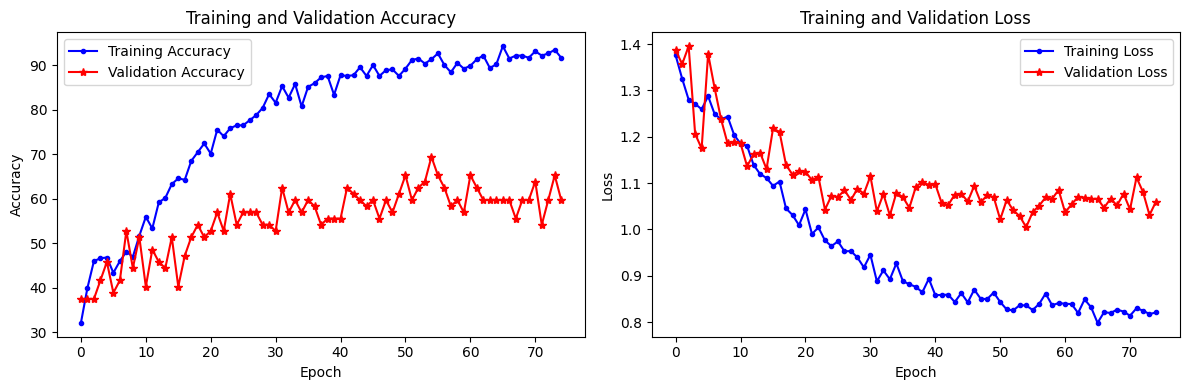

In [32]:
cnn = train_cnn(num_epochs=150, cnn=cnn, train_loader=train_loader, val_loader=val_loader)

In [18]:
cnn = CustomCNN().to(device)  # Create fresh instance
cnn.load_state_dict(torch.load('trained_model.pth'))  # Load weights
cnn.eval() 
print("Pretrained model loaded successfully")


Pretrained model loaded successfully


In [ ]:
# Calculate metrics for Enhanced CNN model
cnn.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = cnn(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.3683
Precision: 0.3850
Recall: 0.4111
F1-score: 0.3623


In [45]:
def grad_cam(model, image_tensor, original_image, target_layer_name=None):
    """Universal Grad-CAM function that works with both ResNet and CustomCNN"""
    model.eval()
    
    # Default target layers
    if target_layer_name is None:
        if isinstance(model, CustomCNN):
            target_layer_name = "conv3"
        else:  # ResNet
            target_layer_name = "layer4.2.conv3"  
    
    # Hook containers
    activations = []
    gradients = []
    
    # Forward hook
    def forward_hook(module, input, output):
        #print("Forward hook called")
        activations.append(output.detach())
    
    # Backward hook
    def backward_hook(module, grad_input, grad_output):
        #print("Backward hook called")
        gradients.append(grad_output[0].detach())
    
    # Find target layer
    target_layer = None
    for name, module in model.named_modules():
        if name == target_layer_name:
            target_layer = module
            break
    
    if target_layer is None:
        raise ValueError(f"Target layer {target_layer_name} not found in model")
    
    # Register hooks
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)
    
    # Forward pass - ensure image is normalized and on correct device
    image_tensor = image_tensor.unsqueeze(0).to(device)
    outputs = model(image_tensor)
    
    # Backward pass
    model.zero_grad()
    predicted_class = outputs.argmax(dim=1).item()
    score = outputs[0, predicted_class]
    score.backward()
    
    # Remove hooks
    forward_handle.remove()
    backward_handle.remove()
    
    # Check if hooks captured data
    if not activations or not gradients:
        raise RuntimeError("Failed to capture gradients or activations. Check your target layer.")
    
    # Process CAM
    activations = activations[0].squeeze()
    gradients = gradients[0].squeeze()
    
    # Pool gradients spatially
    weights = torch.mean(gradients, dim=[1, 2])  # [channels]
    
    # Weight activations by pooled gradients
    cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)
    for i, w in enumerate(weights):
        cam += w * activations[i, :, :]
    
    # Normalize and resize
    cam = torch.relu(cam)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cam.detach().cpu().numpy()
    cam = cv2.resize(cam, (original_image.shape[1], original_image.shape[0]))
    
    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    superimposed_img = heatmap * 0.4 + original_image * 0.6
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
    
    # Visualize
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [40]:
# Check if the backward hook works correctly
# Pick a sample image
sample_images, _ = next(iter(val_loader))
sample_image = sample_images[0].unsqueeze(0).to(device)

# Attach a backward hook to the target layer
target_layer = dict(resnet.named_modules())["layer4.1.conv3"]
def test_backward_hook(module, grad_input, grad_output):
    print("Test backward hook called")
hook = target_layer.register_full_backward_hook(test_backward_hook)

# Forward pass
output = resnet(sample_image)
score = output[0, output.argmax(dim=1)]
score.backward()

hook.remove()

Test backward hook called


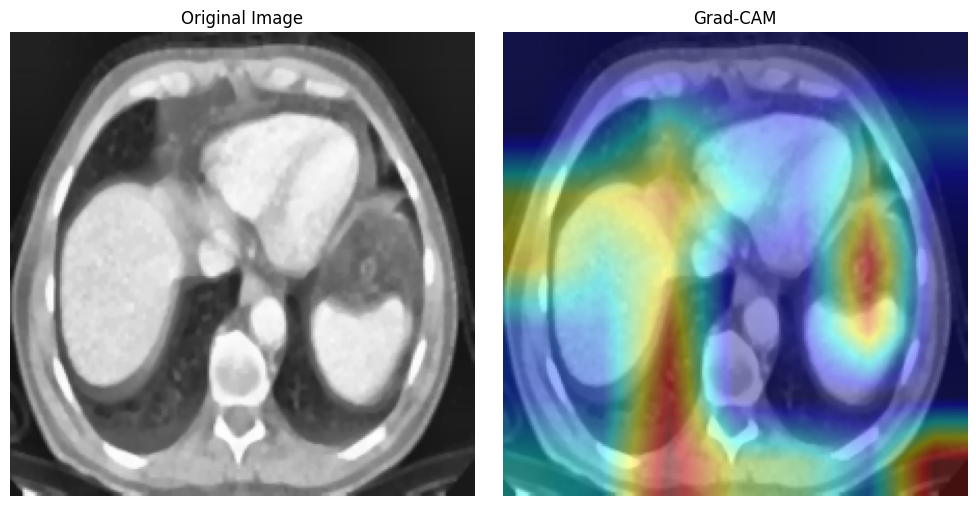

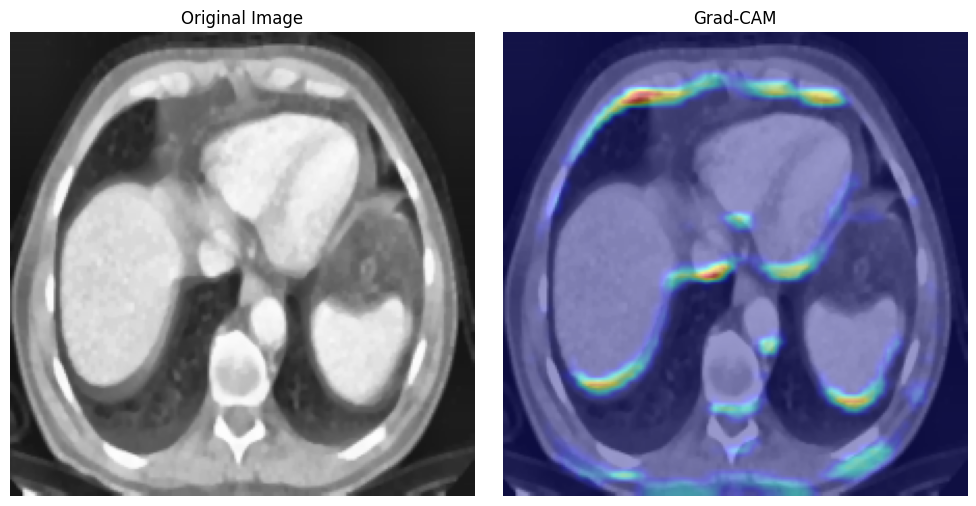

In [46]:
resnet.eval()
cnn.eval()

sample_images, _ = next(iter(val_loader))
sample_image = sample_images[2]
original_image = sample_image.permute(1, 2, 0).cpu().numpy()
original_image = (original_image * 255).astype(np.uint8)

grad_cam(resnet, sample_image, original_image, target_layer_name="layer4.2.conv3")
grad_cam(cnn, sample_image, original_image, target_layer_name="conv3")